# Analysis of slope

Images from pipeline: MNISym_coreg_normalize --> MNISym_coreg_regression

Using slope images for each subject for each of: T1 anatomical, segmentations (GM, WM, CSF), log of Jacobian determinant.

ROIs are defined by the atlas "Diedrichsen_2009" (original SUIT atlas) using anatomical labels.

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import smarts_cerebellum.globals as gl

In [15]:
path = os.path.join(gl.baseDir, 'Regression')

Make this presentable; make it a story for how we did it the other day.

So the first thing is:

Look at the surface_projection of the overall image.

Then, for each subject, look at the mean, median in each of these lobules for all our measurements.

See (deprecated) MNISym_coreg_regression.ipynb

**note that  CUP_1001 (control) is treated as an outlier here**

In [16]:
df = pd.read_csv(f'{path}/MNISym_coreg_slope_rightLesion_AtlasSUIT_summarized.tsv', sep = '\t')

In [17]:
df=df[df.subj_id != 'CUP_1001']

In [18]:
#df = pd.read_csv(f'{path}/MNISym_coreg_slope_rightLesion_AtlasSUIT_summarized.tsv', sep = '\t')

# using the areas identified in "surface_projections.ipynb"
rois = ['Left_I_IV', 'Right_I_IV', 'Left_V', 'Right_V', 'Left_VI', 'Right_VI']

df_rois_CSF = df[df.regionname.isin(rois) & (df.image==4)]
df_rois_GM = df[df.regionname.isin(rois) & (df.image==2)]

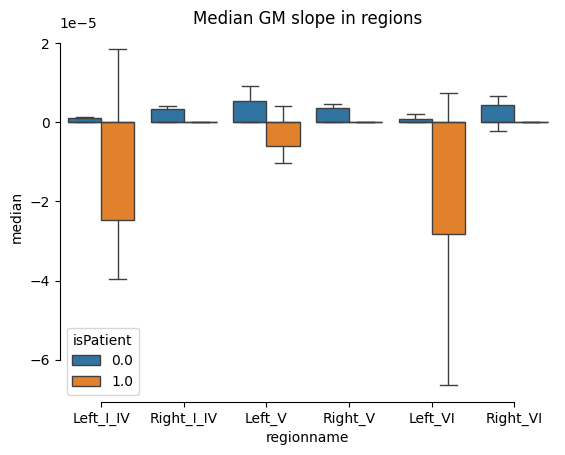

In [19]:
sns.boxplot(data=df_rois_GM, x='regionname', y='median', hue='isPatient', showfliers=False )

sns.despine(trim = True)
plt.title('Median GM slope in regions')
plt.show()

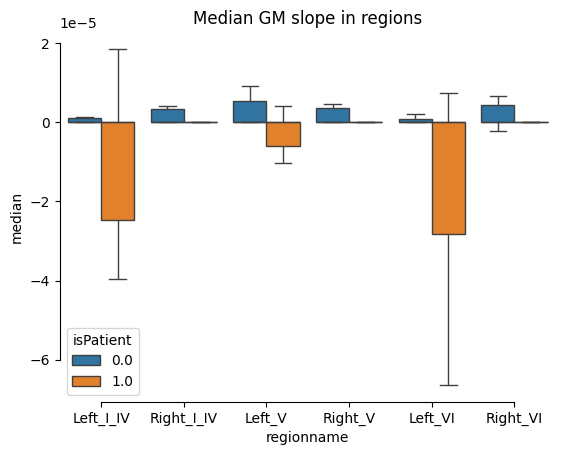

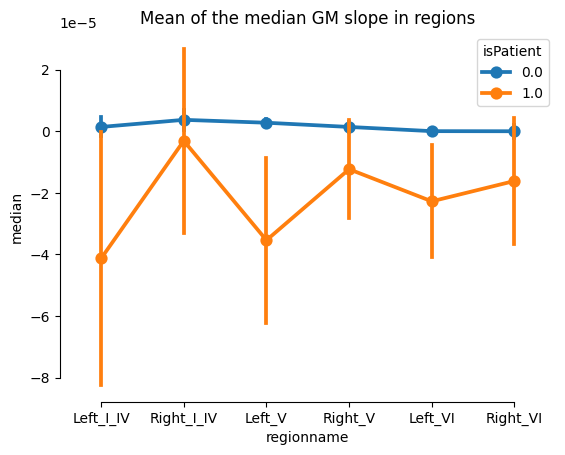

In [20]:
sns.pointplot(data=df_rois_GM, x='regionname', y='median', hue='isPatient', errorbar='se', estimator='mean')

sns.despine(trim = True)
plt.title('Mean of the median GM slope in regions')
plt.show()

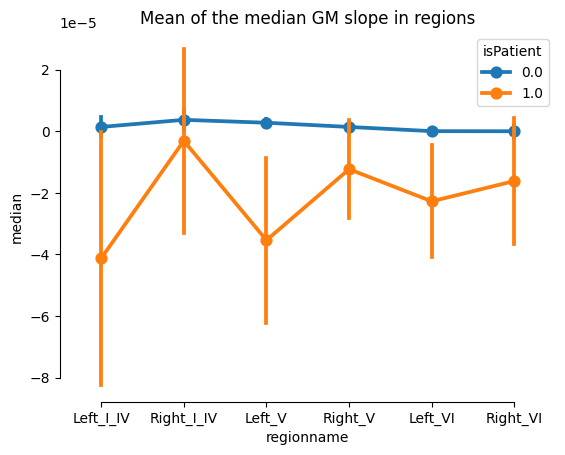
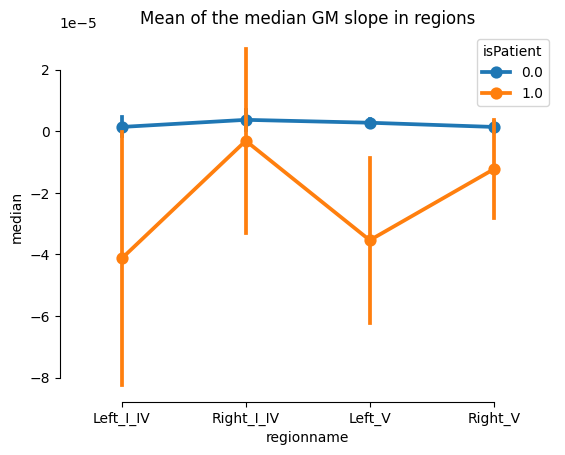

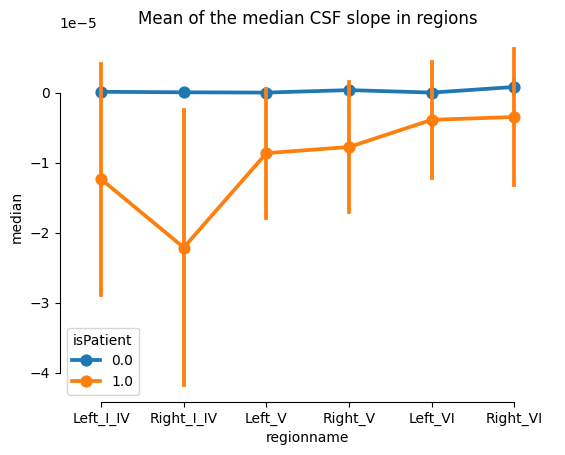

In [21]:
sns.pointplot(data=df_rois_CSF, x='regionname', y='median', hue='isPatient', errorbar='se', estimator='mean')

sns.despine(trim = True)
plt.title('Mean of the median CSF slope in regions')
plt.show()

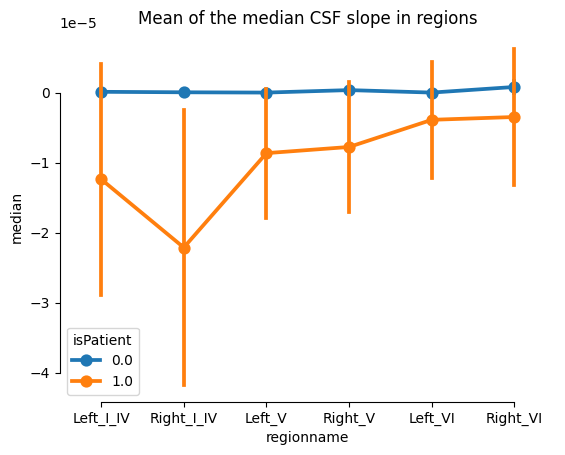
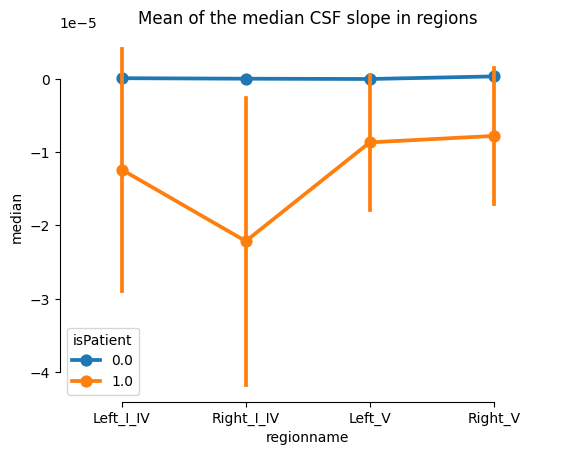

## Hemispheric changes: see changes in hemispheres relative to lesion

This would be: ipsilesional, contralesional, vermis, control

The idea would be to have somehting like we did for our WMV (images from native space resliced into SUIT template, then using SUIT atlas).

So perhaps for each subject, for each image_type, for each hemisphere, we can plot their overall change.

What does it mean to take the average and sum of voxels in each region in an atlas?

So we have a slope image for each subject, which is the change in each voxel - and then with the sum, we get the overall change (for ALL voxels) in an ROI; we can also get the mean change in that area.

For the hand area and grey matter (cortex), we can use the Nettekoven atlas.